# Modelling SVM — Sentimen MBG

Notebook ini fokus ke **training model SVM** untuk klasifikasi sentimen program Makan Bergizi Gratis (MBG).

Data yang dipakai sudah melalui pipeline sebelumnya:
1. `data_clean.py` → bersihin teks → `cleaned.csv`
2. `llm_labelling.py` → labeling DeepSeek → `labeled.csv`
3. `sample_manual.py` → split 300 review manual → `manual_labeled.csv`
4. Merge manual priority → `labeled_v2.csv`

---
### Alur Notebook Ini:
1. Import & Setup
2. Baca data berlabel
3. TF‑IDF Vectorization
4. Train / Test Split
5. Grid Search Tuning + Training SVM
6. Evaluasi
7. Simpan Model
8. Demo Prediksi
9. Wordcloud

---
## 1. Import & Setup

In [5]:
import os

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")
%matplotlib inline

# ── Paths ─────────────────────────────────────────────────────────────
LABELED_V2_CSV = "../../dataset/labeled/labeled_v2.csv"
MODEL_DIR = "../models"
MODEL_PATH = os.path.join(MODEL_DIR, "svm_sentiment.pkl")
VECTORISER_PATH = os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")

---
## 2. Baca Data Berlabel

Pakai `labeled_v2.csv` — gabungan manual_labeled (prioritas) + labeled (DeepSeek).

[DATA] 7172 baris siap training
       Label: {'negatif': np.int64(2999), 'positif': np.int64(2334), 'netral': np.int64(1839)}


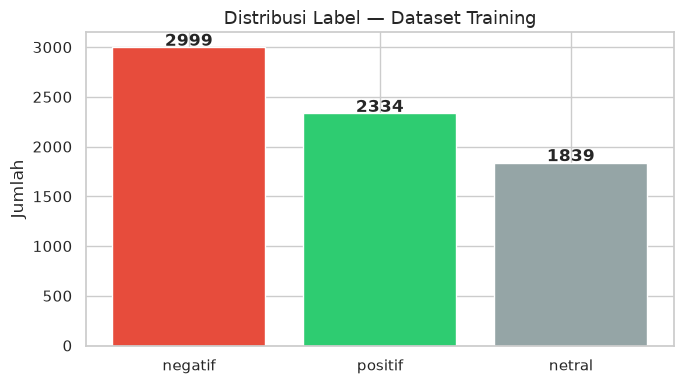

In [6]:
# ── Baca data ─────────────────────────────────────────────────────────
df = pd.read_csv(LABELED_V2_CSV)
X = df["text"].astype(str)
y = df["label"]

print(f"[DATA] {len(df)} baris siap training")
print(f"       Label: {dict(y.value_counts())}")

# ── Plot distribusi label ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors_map = {"positif": "#2ecc71", "negatif": "#e74c3c", "netral": "#95a5a6"}
counts = y.value_counts()
bars = ax.bar(counts.index, counts.values, color=[colors_map.get(l, "gray") for l in counts.index])
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15, str(v),
            ha="center", fontweight="bold", fontsize=12)
ax.set_title("Distribusi Label — Dataset Training", fontsize=13)
ax.set_ylabel("Jumlah")
plt.tight_layout()
plt.show()

---
## 3. TF‑IDF Vectorization

Ubah teks jadi vektor numerik. Pakai unigram + bigram, maks 10.000 fitur, `sublinear_tf` untuk menormalkan frekuensi kata.

In [7]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True,
)

X_tf = tfidf.fit_transform(X)
print(f"[TF-IDF] Shape: {X_tf.shape}  (baris × fitur)")

[TF-IDF] Shape: (7172, 10000)  (baris × fitur)


---
## 4. Train / Test Split

Split 80:20 **stratified** — proporsi label di train & test tetap seimbang.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tf, y, test_size=0.2, random_state=42, stratify=y,
)

print(f"[SPLIT] Train : {X_train.shape[0]} baris")
print(f"        Test  : {X_test.shape[0]} baris")
print(f"        Train label : {dict(y_train.value_counts())}")
print(f"        Test label  : {dict(y_test.value_counts())}")

[SPLIT] Train : 5737 baris
        Test  : 1435 baris
        Train label : {'negatif': np.int64(2399), 'positif': np.int64(1867), 'netral': np.int64(1471)}
        Test label  : {'negatif': np.int64(600), 'positif': np.int64(467), 'netral': np.int64(368)}


---
## 5. Grid Search Tuning + Training SVM

- `kernel='linear'` — cocok untuk data teks dengan TF-IDF
- `class_weight='balanced'` — menangani kelas tidak seimbang (netral lebih sedikit)
- `C` — parameter regularisasi (0.1, 1, 10, 100)
- Scoring: `f1_macro` — rata-rata F1 semua kelas, adil untuk kelas minoritas

In [9]:
param_grid = {"C": [0.1, 1, 10, 100]}

grid = GridSearchCV(
    SVC(kernel="linear", class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    verbose=1,
)

print("Memulai GridSearchCV (4 candidate × 5 folds = 20 fits)...\n")
grid.fit(X_train, y_train)

print(f"\n[TUNING] Parameter terbaik : {grid.best_params_}")
print(f"[TUNING] CV f1_macro        : {grid.best_score_:.4f}")

model = grid.best_estimator_

Memulai GridSearchCV (4 candidate × 5 folds = 20 fits)...

Fitting 5 folds for each of 4 candidates, totalling 20 fits

[TUNING] Parameter terbaik : {'C': 1}
[TUNING] CV f1_macro        : 0.7460


---
## 6. Evaluasi

Prediksi pada test set, tampilkan **classification report** & **confusion matrix**.

Classification Report
              precision    recall  f1-score   support

     negatif       0.75      0.79      0.77       600
      netral       0.56      0.60      0.58       368
     positif       0.88      0.77      0.83       467

    accuracy                           0.74      1435
   macro avg       0.73      0.72      0.72      1435
weighted avg       0.74      0.74      0.74      1435



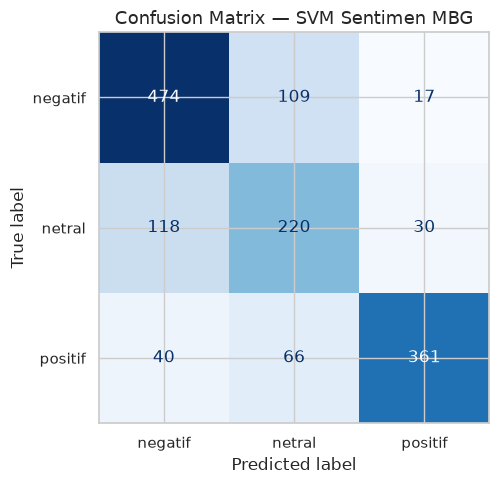

In [10]:
y_pred = model.predict(X_test)

# ── Classification Report ─────────────────────────────────────────────
print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred))

# ── Confusion Matrix (heatmap) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=["negatif", "netral", "positif"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negatif", "netral", "positif"],
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — SVM Sentimen MBG", fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Simpan Model

Simpan SVM & TF‑IDF vectorizer ke `ml/models/` untuk dipakai di production (`predict.py`).

In [11]:
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)
joblib.dump(tfidf, VECTORISER_PATH)

print(f"[SAVE] {MODEL_PATH}")
print(f"[SAVE] {VECTORISER_PATH}")
print("\n✅ Model siap digunakan!")

[SAVE] ../models/svm_sentiment.pkl
[SAVE] ../models/tfidf_vectorizer.pkl

✅ Model siap digunakan!


---
## 8. Demo Prediksi

Coba prediksi 5 teks contoh Bahasa Indonesia.

In [13]:
contoh_teks = [
    "Program makan bergizi gratis ini sangat membantu anak-anak kurang mampu, semoga terus berlanjut!",
    "Makan bergizi gratis katanya, tapi kenyataannya menunya tidak layak dan porsinya sangat kurang",
    "Pemerintah resmi meluncurkan program makan bergizi gratis untuk siswa SD di seluruh Indonesia",
    "Daftar jadi mitra MBG gampang banget, langsung cuan deh! Makasih pak Prabowo",
    "Sudah seminggu program MBG berjalan tapi sekolah kami belum dapat sama sekali, kemana anggarannya?",
]

emoji_map = {"positif": "👍", "negatif": "👎", "netral": "➖"}

for i, teks in enumerate(contoh_teks, 1):
    pred = model.predict(tfidf.transform([teks]))[0]
    print(f"[{i}] {teks}")
    print(f"    Sentimen: {emoji_map.get(pred, '?')} {pred}\n")

[1] Program makan bergizi gratis ini sangat membantu anak-anak kurang mampu, semoga terus berlanjut!
    Sentimen: 👍 positif

[2] Makan bergizi gratis katanya, tapi kenyataannya menunya tidak layak dan porsinya sangat kurang
    Sentimen: 👎 negatif

[3] Pemerintah resmi meluncurkan program makan bergizi gratis untuk siswa SD di seluruh Indonesia
    Sentimen: ➖ netral

[4] Daftar jadi mitra MBG gampang banget, langsung cuan deh! Makasih pak Prabowo
    Sentimen: 👍 positif

[5] Sudah seminggu program MBG berjalan tapi sekolah kami belum dapat sama sekali, kemana anggarannya?
    Sentimen: 👎 negatif



---
## 9. Wordcloud

Visualisasi kata paling dominan dari seluruh dataset bersih.

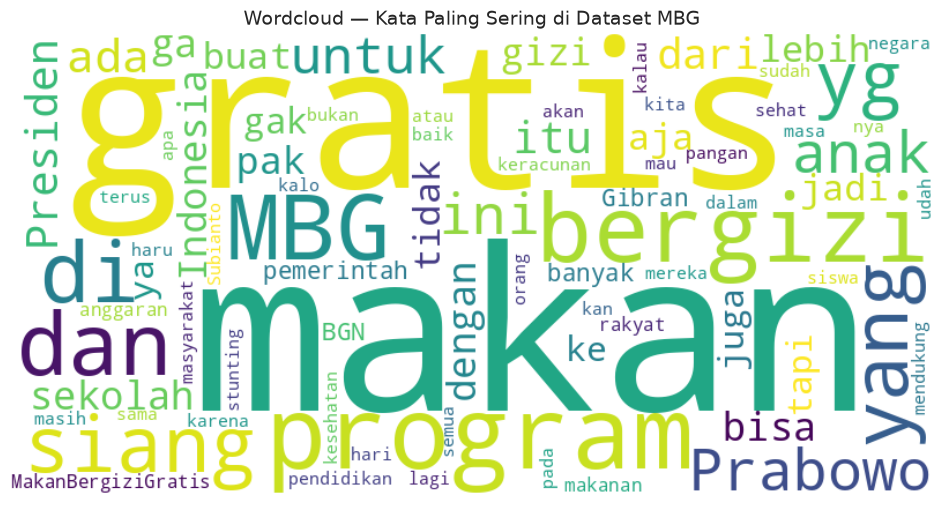

In [14]:
all_text = " ".join(df["text"].dropna().astype(str))
wc = WordCloud(
    width=800, height=400,
    background_color="white",
    colormap="viridis",
    max_words=80,
    collocations=False,
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud — Kata Paling Sering di Dataset MBG", fontsize=14)
plt.show()

---

## ✅ Selesai!

Model SVM & TF‑IDF vectorizer sudah tersimpan dan siap dipakai:

- `ml/models/svm_sentiment.pkl`
- `ml/models/tfidf_vectorizer.pkl`

Gunakan `predict.py` untuk CLI interaktif.